# IPCA – Alimentação e Bebidas (IBGE/SIDRA)

Este notebook apresenta:

**1. O que é o grupo Alimentação e Bebidas no IPCA**  
**2. Como o IBGE organiza os grupos e subgrupos**  
**3. Execução do pipeline (IBGE – tabela 1419)**  
**4. Consulta ao banco de dados**  
**5. Gráficos e análises profissionais**  

Vamos começar entendendo o conceito.

# 1. O que é o grupo Alimentação e Bebidas?

O grupo **Alimentação e Bebidas** é o mais importante do IPCA:

- representa cerca de **20%** do índice  
- é altamente volátil  
- responde a choques climáticos, safras e commodities  

O IBGE organiza esse grupo em **subgrupos oficiais**, como:

- alimentação no domicílio  
- alimentação fora do domicílio  
- carnes  
- leite e derivados  
- frutas  
- hortaliças e verduras  

Esses subgrupos são obtidos pela **tabela 1419 do SIDRA**.

# 2. Subgrupos oficiais (IBGE – Tabela 1419)

O grupo Alimentação e Bebidas tem código **7169** na classificação 315 do IBGE.

A tabela 1419 contém:

- variação mensal  
- por grupo  
- por subgrupo  
- por item  

Para este notebook, usamos:

- **variável 63** → Variação mensal do IPCA  
- **classificação 315** → Grupos do IPCA  
- **código 7169** → Alimentação e bebidas

# 3. Ajustar o PYTHONPATH para importar `src/`

In [1]:
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.append(ROOT)
print("PYTHONPATH atualizado:", ROOT)

PYTHONPATH atualizado: /home/moacir/projects/ml/analytics/inflation


# 4. Importações

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.pipelines.ipca_alimentacao import run_ipca_alimentacao
from src.database.connection import engine

# 5. Executar pipeline IPCA Alimentação (IBGE)

Isso irá:
- consultar a tabela 1419 do SIDRA  
- filtrar o grupo 7169 (Alimentação e bebidas)  
- criar a tabela `ibge.ipca_alimentacao`  
- inserir todos os dados no PostgreSQL

In [7]:
run_ipca_alimentacao()

2026-04-20 10:08:31,102 | INFO | src.api.sidra_client | Consultando SIDRA: tabela=1419, variavel=63, periodo=all
2026-04-20 10:08:31,740 | INFO | src.api.sidra_client | Pipeline para conversão de valores concluído com sucesso.


True

# 6. Verificar tabelas existentes no schema `ibge`

In [8]:
pd.read_sql("""
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'bcb'
ORDER BY table_name;
""", engine)

,table_name
0,ipca
1,ipca_alimentacao
2,ipca_habitacao
3,selic_meta
4,selic_over


# 7. Carregar dados do IPCA Alimentação

In [11]:
df = pd.read_sql("SELECT * FROM bcb.ipca_alimentacao ORDER BY date desc;", engine)
df.head()

,date,alimentacao_e_bebidas,alimentacao_no_domicilio,alimentacao_fora_do_domicilio,cereais_leguminosas_oleaginosas,carnes,leite_e_derivados,frutas,tuberculos_raizes_legumes,panificados
0,2019-12-01,1.15,3.38,4.69,5.73,0.17,None,1.53,4.53,6.54
1,2019-12-01,1.15,3.38,4.69,5.73,0.17,None,1.53,4.53,6.54
2,2019-12-01,1.15,3.38,4.69,5.73,0.17,None,1.53,4.53,6.54
3,2019-11-01,0.51,0.72,1.01,1.65,0.69,None,-8.15,-1.71,4.53
4,2019-11-01,0.51,0.72,1.01,1.65,0.69,None,-8.15,-1.71,4.53


# 8. Últimos valores

In [6]:
df.tail(12)

,date,alimentacao_e_bebidas,alimentacao_no_domicilio,alimentacao_fora_do_domicilio,cereais_leguminosas_oleaginosas,carnes,leite_e_derivados,frutas,tuberculos_raizes_legumes,panificados
180,2019-07-01,0.19,0.01,-0.06,-2.00,0.48,None,-0.45,-3.48,1.39
181,2019-07-01,0.19,0.01,-0.06,-2.00,0.48,None,-0.45,-3.48,1.39
182,2019-08-01,0.11,-0.35,-0.84,-0.32,0.67,None,0.37,-0.94,-0.02
183,2019-08-01,0.11,-0.35,-0.84,-0.32,0.67,None,0.37,-0.94,-0.02
184,2019-09-01,-0.04,-0.43,-0.70,-0.63,0.63,None,-8.66,-1.90,-1.45
185,2019-09-01,-0.04,-0.43,-0.70,-0.63,0.63,None,-8.66,-1.90,-1.45
186,2019-10-01,0.10,0.05,-0.03,-0.20,0.05,None,-4.30,-2.78,0.65
187,2019-10-01,0.10,0.05,-0.03,-0.20,0.05,None,-4.30,-2.78,0.65
188,2019-11-01,0.51,0.72,1.01,1.65,0.69,None,-8.15,-1.71,4.53
189,2019-11-01,0.51,0.72,1.01,1.65,0.69,None,-8.15,-1.71,4.53


# 9. Estatísticas básicas

In [7]:
df.describe()

,date,alimentacao_e_bebidas,alimentacao_no_domicilio,alimentacao_fora_do_domicilio,cereais_leguminosas_oleaginosas,carnes,frutas,tuberculos_raizes_legumes,panificados
count,192,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000
mean,2015-12-16 11:00:00,0.466875,0.557292,0.546875,0.637708,0.574792,0.923854,0.832813,0.620208
min,2012-01-01 00:00:00,-0.230000,-1.070000,-1.840000,-6.010000,-1.980000,-19.730000,-9.220000,-8.310000
25%,2013-12-24 06:00:00,0.247500,0.010000,-0.215000,-1.537500,-0.392500,-3.062500,-2.087500,-2.867500
50%,2015-12-16 12:00:00,0.430000,0.580000,0.555000,-0.120000,0.370000,-0.120000,-0.085000,-0.005000
75%,2017-12-08 18:00:00,0.612500,0.962500,1.077500,2.277500,1.097500,3.050000,2.790000,3.500000
max,2019-12-01 00:00:00,1.320000,3.380000,4.690000,17.510000,9.880000,34.150000,41.590000,14.720000
std,NaN,0.326605,0.724816,1.031050,3.780719,1.787684,8.267757,6.265450,4.861125


# 10. Gráfico da variação mensal do grupo Alimentação

A série representa a **variação mensal (%)** do grupo Alimentação e Bebidas.

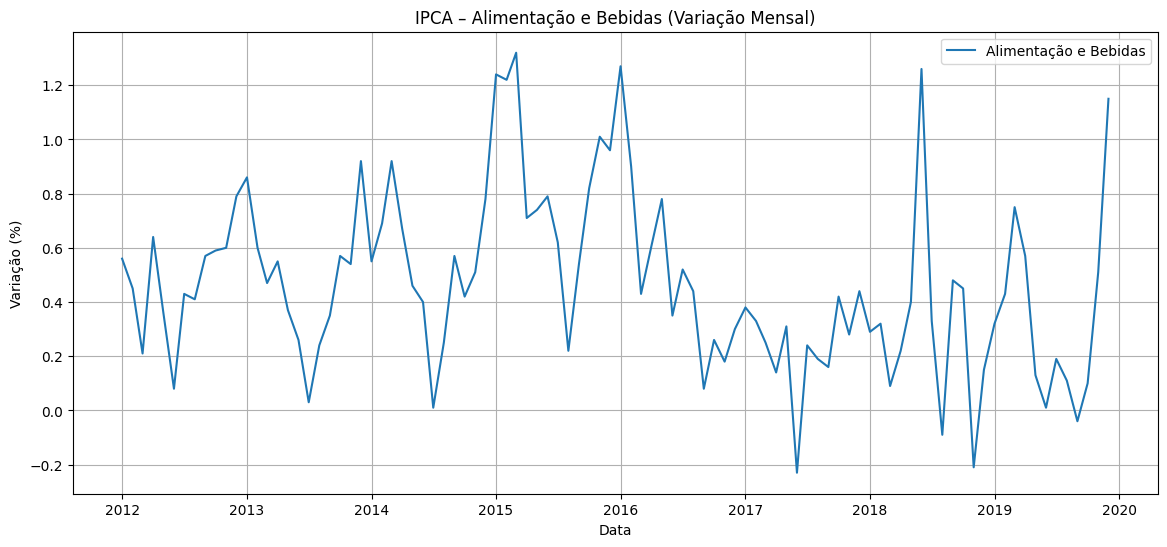

In [9]:
plt.figure(figsize=(14, 6))
plt.plot(df["date"], df["alimentacao_e_bebidas"], label="Alimentação e Bebidas")

plt.title("IPCA – Alimentação e Bebidas (Variação Mensal)")
plt.xlabel("Data")
plt.ylabel("Variação (%)")
plt.grid(True)
plt.legend()
plt.show()

# 11. Heatmap dos últimos 24 meses

Útil para visualizar aceleração e desaceleração.

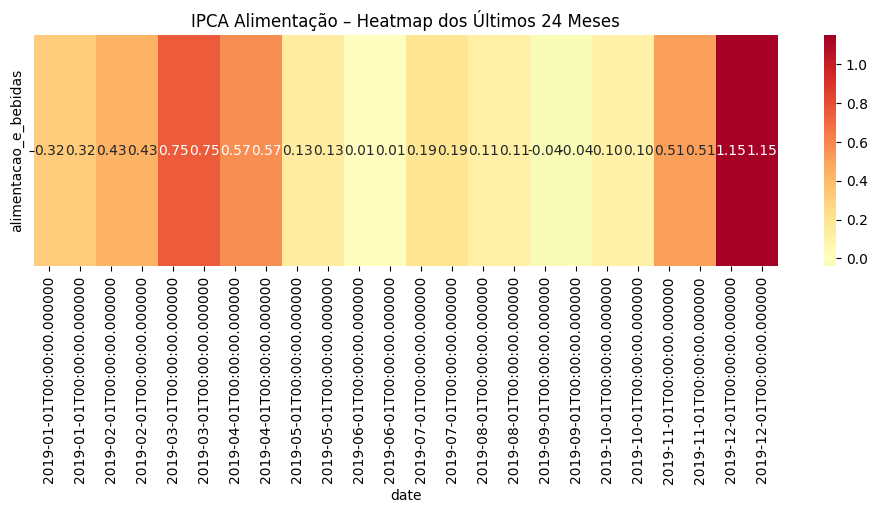

In [10]:
df_hm = df.set_index("date").tail(24)

plt.figure(figsize=(12, 3))
sns.heatmap(
    df_hm[["alimentacao_e_bebidas"]].T,
    cmap="RdYlGn_r",
    center=0,
    annot=True,
    fmt=".2f"
)
plt.title("IPCA Alimentação – Heatmap dos Últimos 24 Meses")
plt.show()

# 12. Média móvel de 12 meses

Ajuda a visualizar tendências estruturais.

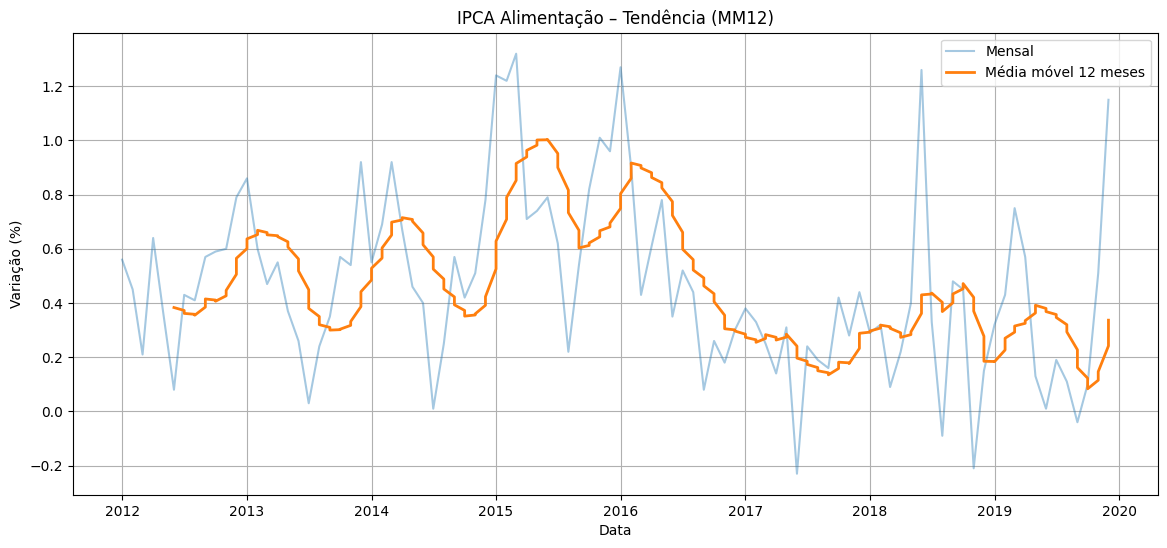

In [11]:
df["mm12"] = df["alimentacao_e_bebidas"].rolling(12).mean()

plt.figure(figsize=(14, 6))
plt.plot(df["date"], df["alimentacao_e_bebidas"], alpha=0.4, label="Mensal")
plt.plot(df["date"], df["mm12"], linewidth=2, label="Média móvel 12 meses")

plt.title("IPCA Alimentação – Tendência (MM12)")
plt.xlabel("Data")
plt.ylabel("Variação (%)")
plt.grid(True)
plt.legend()
plt.show()

# 13. Conclusões

- O grupo Alimentação é o mais volátil do IPCA.  
- Choques climáticos e safras afetam fortemente frutas, hortaliças e carnes.  
- A média móvel de 12 meses ajuda a identificar tendências estruturais.  
- A tabela `ibge.ipca_alimentacao` agora está sempre atualizada pelo pipeline.

Próximos passos:
- Criar o pipeline dos subgrupos (tabela 7060)  
- Criar o pipeline dos outros 8 grupos  
- Criar o consolidado dos 9 grupos  
- Reconstruir o IPCA geral a partir dos grupos  